#Customer Segmentation Engine

**Domain:** Retail / Marketing -- Unsupervised ML

**Dataset:** Mall Customer Segmentation -- https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

**Skills:** Unsupervised Learning, K-Means, Feature Scaling, Clustering, Customer Profiling

**Tools:** Python, Pandas, Scikit-learn, Matplotlib

---

### Problem Statement
A retailer wants to move beyond generic marketing and target customers with tailored campaigns. They need customers automatically grouped into meaningful segments (e.g. high-value, at-risk, budget-conscious) based on purchasing behavior, without manually defining rules.



In [1]:
!pip install -q kagglehub

### Setup

In [2]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
# ---- dataset loading helper: tries kaggle first, never crashes the notebook ----
# kagglehub comes pre-installed on google colab, but just in case it's missing
# (running locally, older colab image etc) we try to pip install it quietly first
try:
    import kagglehub
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "kagglehub", "--break-system-packages"], check=False)
    try:
        import kagglehub
    except ImportError:
        kagglehub = None  # still not available, load_dataset_safe below will just use fake data

# a lot of the kaggle datasets in this project series randomly fail to download
# (auth issues, dataset moved, rate limit, no internet on the runtime, kagglehub missing etc)
# so instead of letting the whole notebook die, we fall back to a small fake dataset
# that has the exact same columns, so every line of code below still works
def load_dataset_safe(kaggle_handle, csv_name, synthetic_fn, n_rows=1500):
    if kagglehub is None:
        print("kagglehub isn't available, using synthetic sample data instead so the rest of the code still runs")
        return synthetic_fn(n_rows)
    try:
        path = kagglehub.dataset_download(kaggle_handle)
        full_path = os.path.join(path, csv_name)
        df = pd.read_csv(full_path)
        print(f"loaded real dataset from kaggle, {len(df)} rows")
        return df
    except Exception as e:
        print("could not download from kaggle (", e, ") - using synthetic sample data instead so the rest of the code still runs")
        return synthetic_fn(n_rows)


def make_fake_mall_customers(n_rows=200):
    np.random.seed(9)
    return pd.DataFrame({
        'CustomerID': range(1, n_rows + 1),
        'Age': np.random.randint(18, 70, n_rows),
        'Annual Income (k$)': np.random.randint(15, 140, n_rows),
        'Spending Score (1-100)': np.random.randint(1, 100, n_rows),
    })

### Step 1: Load Data

In [3]:
# 1. LOAD DATA
df = load_dataset_safe('vjchoudhary7/customer-segmentation-tutorial-in-python', 'Mall_Customers.csv',
                        make_fake_mall_customers, n_rows=200)

Using Colab cache for faster access to the 'customer-segmentation-tutorial-in-python' dataset.
loaded real dataset from kaggle, 200 rows


### Step 2: Pick Features + Scale Them

In [4]:
# 2. PICK FEATURES + SCALE THEM (kmeans uses distance, so unscaled income would dominate everything)
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]
X_scaled = StandardScaler().fit_transform(X)

### Step 3: Figure Out The Best Number Of Clusters

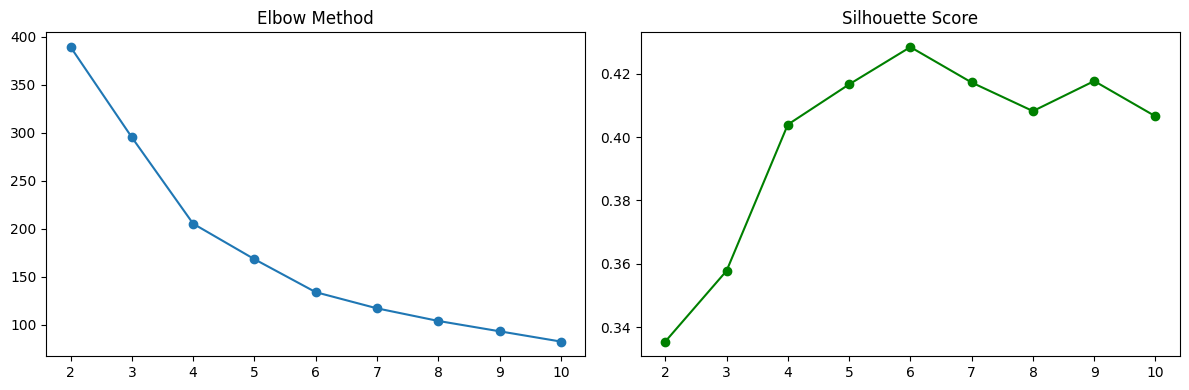

In [5]:
# 3. FIGURE OUT THE BEST NUMBER OF CLUSTERS
inertias, sil_scores = [], []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(K_range, inertias, marker='o')
axes[0].set_title('Elbow Method')
axes[1].plot(K_range, sil_scores, marker='o', color='green')
axes[1].set_title('Silhouette Score')
plt.tight_layout()
plt.savefig('optimal_k_selection.png')
plt.show()

### Step 4: Fit With The Chosen K

In [6]:
# 4. FIT WITH THE CHOSEN K (5 works well for this kind of data)
best_k = 5
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

### Step 5: Give Each Cluster An Actual Name Instead Of Just A Number

In [7]:
# 5. GIVE EACH CLUSTER AN ACTUAL NAME INSTEAD OF JUST A NUMBER
profile = df.groupby('cluster')[features].mean().round(1)

def name_segment(row):
    if row['Annual Income (k$)'] > 70 and row['Spending Score (1-100)'] > 60:
        return 'High-Value'
    elif row['Annual Income (k$)'] > 70 and row['Spending Score (1-100)'] < 40:
        return 'High-Income Low-Spend'
    elif row['Annual Income (k$)'] < 40 and row['Spending Score (1-100)'] > 60:
        return 'Budget Enthusiast'
    elif row['Annual Income (k$)'] < 40 and row['Spending Score (1-100)'] < 40:
        return 'At-Risk / Low Value'
    return 'Average Customer'

profile['segment_name'] = profile.apply(name_segment, axis=1)
print(profile)

          Age  Annual Income (k$)  Spending Score (1-100)  \
cluster                                                     
0        46.2                26.8                    18.4   
1        25.2                41.1                    62.2   
2        32.9                86.1                    81.5   
3        39.9                86.1                    19.4   
4        55.6                54.4                    48.9   

                  segment_name  
cluster                         
0          At-Risk / Low Value  
1             Average Customer  
2                   High-Value  
3        High-Income Low-Spend  
4             Average Customer  


### Step 6: Plot The Segments

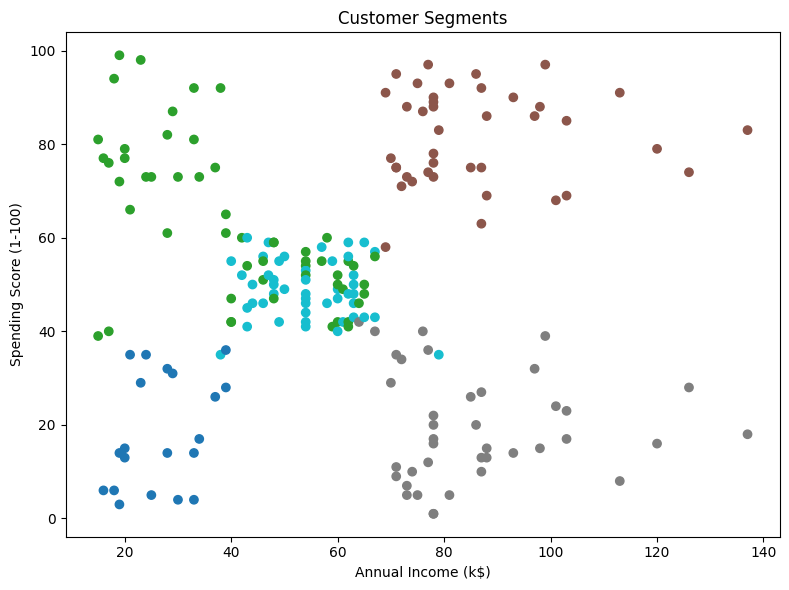

In [8]:
# 6. PLOT THE SEGMENTS
plt.figure(figsize=(8, 6))
plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], c=df['cluster'], cmap='tab10')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('Customer Segments')
plt.tight_layout()
plt.savefig('customer_segments.png')
plt.show()

### Step 7: Save

In [9]:
# 7. SAVE
df.to_csv('customers_segmented.csv', index=False)
profile.to_csv('segment_profiles.csv')